[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/notebooks/01_Descriptive_Research/HMM_InSample_Regime_Analysis_EquityBond.ipynb)




# Stock–Bond Correlation: Characterization of Market Regimes Between the S&P 500 and the 10-Year U.S. Treasury Bond from 1970 to 2025

This code is purely descriptive (fully in-sample). It initializes a Hidden Markov Model (HMM) and fits it to the log returns of the S&P 500 and the 10-year U.S. Treasury Bond from 1970 to 2025, thereby identifying four distinct market regimes. To interpret the economic meaning of each regime, a `RegimeStatisticalAnalyzer` object is used to display regime-conditional means, volatilities, and cross-asset correlations. In addition, statistical tests across regimes are performed (Levene’s test for volatility differences and Fisher’s z-transformation for correlation comparisons).






# Connection to GitHub

In [8]:
import os
import sys

# 1. Environment check
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone the repository
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Move to the project directory
    os.chdir(repo_name)

    # 4. Add the project path to the system path for importing .py modules
    sys.path.append(os.getcwd())

    print(f"Current working directory: {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 966, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 966 (delta 147), reused 73 (delta 73), pack-reused 751 (from 2)
Receiving objects: 100% (966/966), 21.13 MiB | 31.91 MiB/s, done.
Resolving deltas: 100% (462/462), done.
Current working directory: /content/CorrelationEquityBond/CorrelationEquityBond


# Installation of the `ssm` library via the Git repository

In [9]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-59n1cto4
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-59n1cto4
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done


# Imports

In [17]:
import pandas as pd
import numpy as np

from src.stock_bond_correlation.models.HMMMarketRegimeDetector import HMMMarketRegimeDetector
from src.stock_bond_correlation.diagnostics.statistical_tests.HMMCoherenceChecker import HMMCoherenceChecker
from src.stock_bond_correlation.visualization.RegimeReporter import RegimeReporter

# Data preparation

In [10]:
df = pd.read_csv("data/dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

In [11]:
df.head()

,Price,Dividend,Earnings,CPI,Rate GS10,Real Price,Real Dividend,Real Total Return,Real Earnings,Real TR Scaled Earnings,...,PAYEMS,CUMFNS,TCU,UNRATE,DGS10,M2SL,USRECD,PPIACO,AAA_Log_Return,BAA_Log_Return
Date,,,,,,,,,,,,,,,,,,,,,
1934-01-01,10.54,0.44,0.44,13.2,3.12,258.15,10.80,7283.51,10.88,306.96,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.4,NaN,NaN
1934-02-01,11.32,0.44,0.45,13.3,3.09,275.17,10.74,7788.94,10.90,308.46,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.035091,-0.111561
1934-03-01,10.74,0.44,0.45,13.3,3.07,261.07,10.76,7415.24,11.00,312.42,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.016807,-0.001596
1934-04-01,10.92,0.44,0.46,13.3,3.04,265.45,10.78,7565.02,11.10,316.39,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.014634,-0.040755
1934-05-01,9.81,0.44,0.46,13.3,3.01,238.47,10.80,6821.69,11.20,320.43,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.014852,0.006634


In [12]:
ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
asset_names = ["S&P", "T-bond 10y"]
annualise_factor = np.sqrt(12)  # monthly data

cols = ASSET_VARS
df_model = df[cols].dropna().copy()
Y_raw = df_model[ASSET_VARS].values.astype(float)

dates = df_model.index
split_date = pd.Timestamp("2025-01-01")  # descriptive analysis only

train_mask = (dates <= split_date) & (dates >= pd.Timestamp("1970-01-01"))  # analysis starts in 1970
dates_train = dates[train_mask]
Y_train_raw = Y_raw[train_mask]

T, D = Y_raw.shape
SEED = 120
np.random.seed(SEED)

data_to_fit = [Y_train_raw * 100]  # multiplied by 100 for numerical stability

# Initialization and fitting of the descriptive HMM

In [14]:
# HMM model
detector = HMMMarketRegimeDetector(
    n_regimes=4,
    n_dim=2,
    random_state=42
)

detector.fit(observations=data_to_fit)
states = detector.viterbi_states

# Assess model coherence/stability
checker = HMMCoherenceChecker(
    detector=detector,
    log_returns=data_to_fit[0],
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.05
)

checker.report_emission_stats()  # emission parameters
for ref_idx in range(4):
    checker.report_transition_stats(ref_idx=ref_idx)  # transition parameters

checker.final_verdict()  # final automated assessment


COMPLETE EMISSIONS DIAGNOSTIC (BOOTSTRAP & TESTS)

1. ANNUAL VOLATILITIES WITH CONFIDENCE INTERVALS:


Value  Lower_Bound  Upper_Bound
Regime Label                                        
0      S&P         20.7719      16.8046      24.4182
       T-bond 10y   6.3444       5.3222       7.2832
1      S&P          9.4785       8.6795      10.2704
       T-bond 10y   6.0848       5.5967       6.5182
2      S&P         16.5024      13.3366      19.2045
       T-bond 10y  13.5741      10.7680      15.9274
3      S&P          7.0228       6.2479       7.7247
       T-bond 10y   4.7945       4.2415       5.3242


2. CORRELATIONS WITH CONFIDENCE INTERVALS:


,,Value,Lower_Bound,Upper_Bound
Regime,Label,,,
0,S&P / T-bond 10y,-0.4558,-0.6569,-0.2210
1,S&P / T-bond 10y,0.3873,0.3043,0.4644
2,S&P / T-bond 10y,0.2830,0.0785,0.4741
3,S&P / T-bond 10y,-0.1467,-0.3057,0.0176



3. SEPARABILITY TESTS (ALL PAIRS):
- Volatility Significance (Levene):


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,2.2864,0.6093,0.0002,True
1,Intercept,R0 -> R1,Base_Prob,-0.5282,1.0025,0.5983,False
2,Intercept,R0 -> R2,Base_Prob,-0.9240,0.9479,0.3297,False
3,Intercept,R1 -> R0,Base_Prob,0.4373,1.1098,0.6935,False
4,Intercept,R1 -> R1,Base_Prob,4.2535,0.8348,0.0000,True
5,Intercept,R1 -> R2,Base_Prob,-0.0773,1.2368,0.9502,False
6,Intercept,R2 -> R0,Base_Prob,0.0875,1.7392,0.9599,False
7,Intercept,R2 -> R1,Base_Prob,0.9676,1.4925,0.5168,False
8,Intercept,R2 -> R2,Base_Prob,3.4029,1.1994,0.0045,True
9,Intercept,R3 -> R0,Base_Prob,-2.8188,0.4965,0.0000,True



2. AVERAGE DYNAMICS AND PERSISTENCE:


,Average_Duration (months),Stationary_Prob,Stay_Prob
0,5.9528,0.1637,0.8320
1,21.2498,0.4615,0.9529
2,7.3630,0.1113,0.8642
3,11.3100,0.2635,0.9116



HMM COHERENCE REPORT : 80.56%
1. SEPARABILITY : 72.2% (Threshold: 50%) -> OK
2. STABILITY    : VALID
3. PERSISTENCE  : 6.0 months (min 3.0) -> OK
4. CONFIDENCE   : 72.7% (Entropy) -> SOLID
--------------------------------------------------
REGIME DYNAMICS:
   Duration   Freq
0     5.953  0.164
1    21.250  0.461
2     7.363  0.111
3    11.310  0.263

VERDICT: MODEL VALIDATED (Robust)


np.float64(0.8056355505132586)

We therefore appear to identify four distinct market regimes:

1. Flight-to-quality (negative correlation, high volatility, typical of 2008 or 2020)
2. Normal regime (positive correlation, low volatility)
3. Inflationary stress regime (positive correlation, high volatility, typical of the 1970s or 2022)
4. Ideal diversification regime (negative correlation, low volatility, characteristic of the pre-2010 period)

Regarding the statistical tests, the results from Levene’s test and Fisher’s z-transformation are convincing (at least one of the two is significant for each pairwise comparison).

For the transition parameters, the intercepts of self-transitions (from a regime to itself) are significant for all reference states.

Most importantly, we observe the absence of negative eigenvalues in the Fisher information matrix, and the entropy is confirmed.

# Graphical visualization

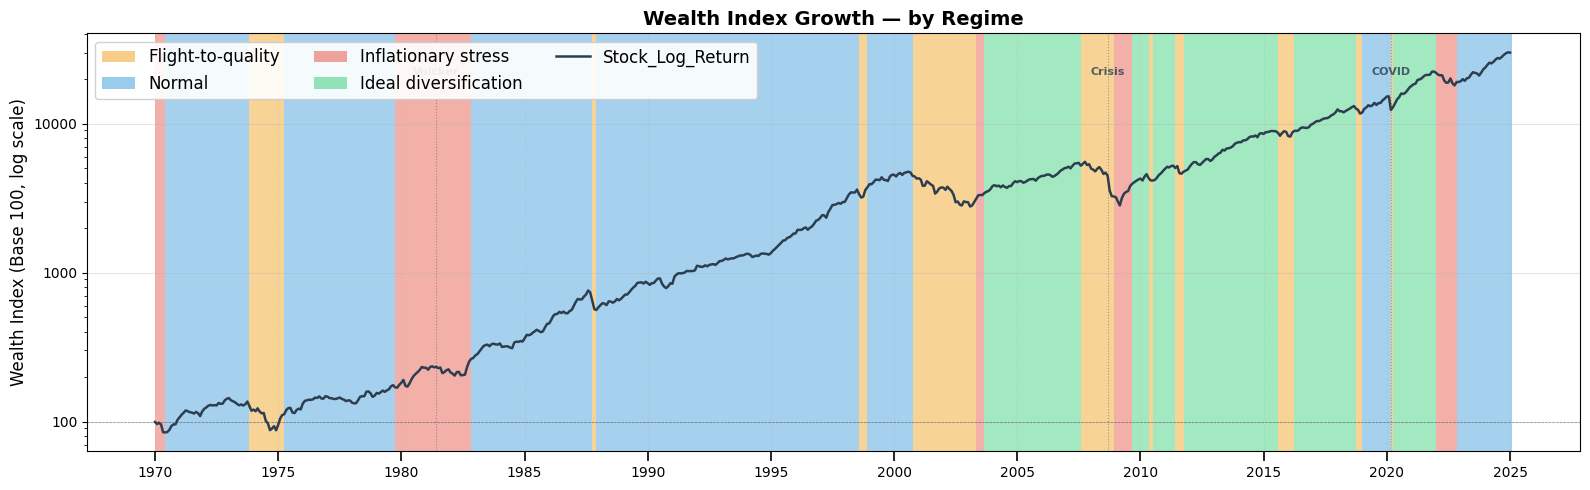

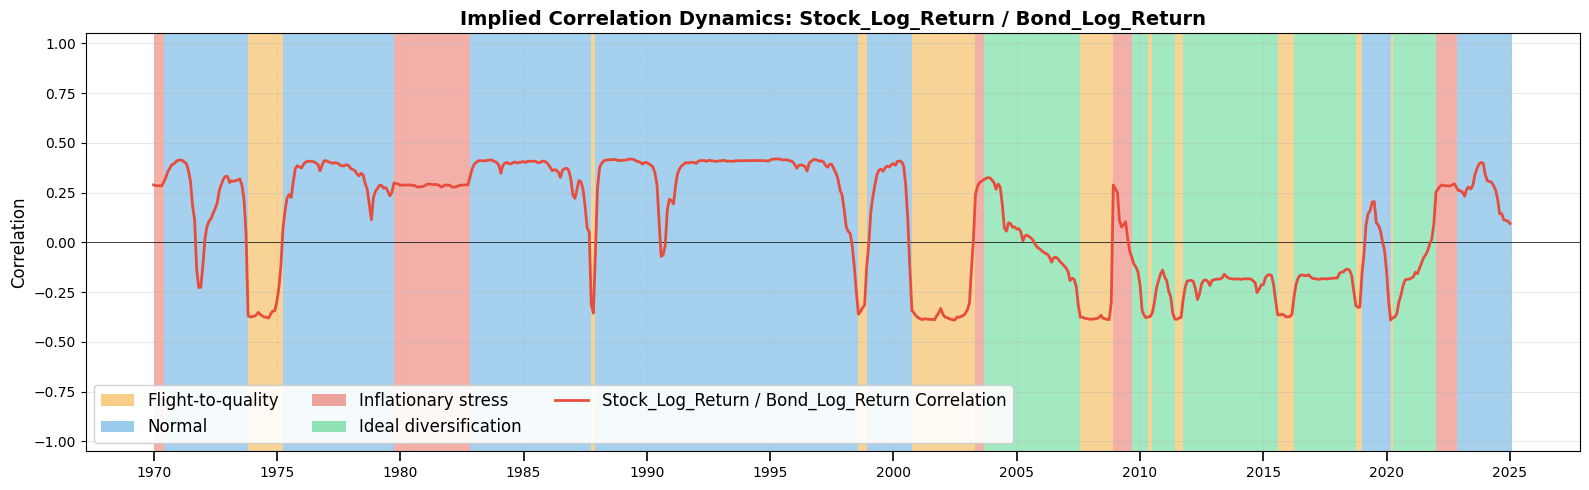

In [15]:
regime_labels = {0: "Flight-to-quality", 1: "Normal", 2: "Inflationary stress", 3: "Ideal diversification"}  # the four identified regimes
regime_colors = {0:"#f39c12", 1: "#3498db", 2: "#e74c3c", 3: "#2ecc71"}  # color choices
crisis_events = {"Volcker": "1981-06-01", "Crisis": "2008-09-01", "COVID": "2020-03-01"}  # key dates for easier identification

# Generic instantiation
visualizer = RegimeReporter(
    detector=detector,
    log_returns=data_to_fit[0] / 100,  # removing the previous scaling by 100
    dates=dates_train,
    states=states,
    asset_names=["Stock_Log_Return", "Bond_Log_Return"],
    regime_labels=regime_labels,
    regime_colors=regime_colors,
    events_dict=crisis_events
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation()